In [ ]:
from google.colab import files
import pandas as pd

print("Please select the CSV file from your local machine to upload:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
    # Assuming the first uploaded file is the one we want to process
    df = pd.read_csv(filename)
    print(f"Successfully loaded '{filename}' into a pandas DataFrame.")
    break # Process only the first file if multiple are uploaded

# Display the first 5 rows of the DataFrame
display(df.head())

Please select the CSV file from your local machine to upload:


Saving drug200.csv to drug200.csv
User uploaded file "drug200.csv" with length 5827 bytes
Successfully loaded 'drug200.csv' into a pandas DataFrame.


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


Decision Tree Accuracy: 1.0


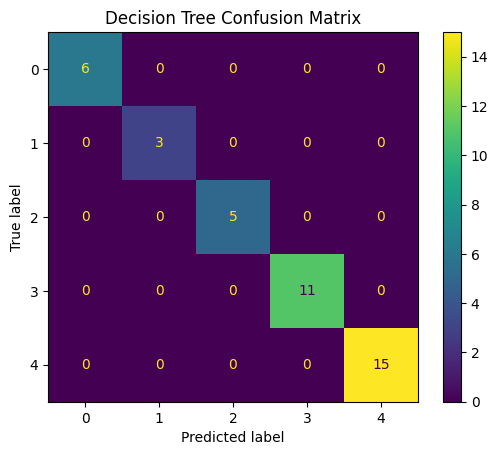

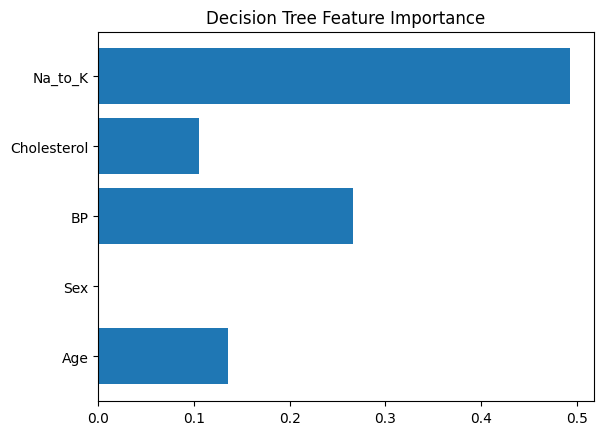

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# =========================
# PART 1 — DECISION TREE (DRUG DATASET)
# =========================

drug_df = pd.read_csv('drug200.csv')

# Encode categorical columns
le = LabelEncoder()
for col in drug_df.columns:
    if drug_df[col].dtype == 'object':
        drug_df[col] = le.fit_transform(drug_df[col])

X_drug = drug_df.drop('Drug', axis=1)
y_drug = drug_df['Drug']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_drug, y_drug, test_size=0.2, random_state=42
)

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train_d, y_train_d)

y_pred_d = dt_model.predict(X_test_d)

print("Decision Tree Accuracy:", accuracy_score(y_test_d, y_pred_d))

# Confusion Matrix
cm_d = confusion_matrix(y_test_d, y_pred_d)
ConfusionMatrixDisplay(cm_d).plot()
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Feature Importance
plt.figure()
plt.barh(X_drug.columns, dt_model.feature_importances_)
plt.title("Decision Tree Feature Importance")
plt.show()

In [ ]:
from google.colab import files
import pandas as pd

print("Please select the CSV file from your local machine to upload:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
    # Assuming the first uploaded file is the one we want to process
    df = pd.read_csv(filename)
    print(f"Successfully loaded '{filename}' into a pandas DataFrame.")
    break # Process only the first file if multiple are uploaded

# Display the first 5 rows of the DataFrame
display(df.head())

Please select the CSV file from your local machine to upload:


Saving Social_Network_Ads.csv to Social_Network_Ads.csv
User uploaded file "Social_Network_Ads.csv" with length 4903 bytes
Successfully loaded 'Social_Network_Ads.csv' into a pandas DataFrame.


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


Random Forest Accuracy: 0.875


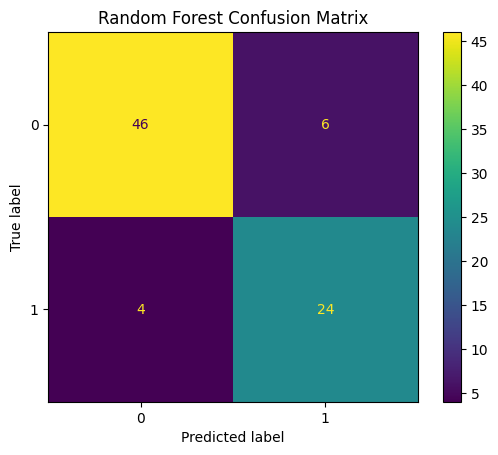

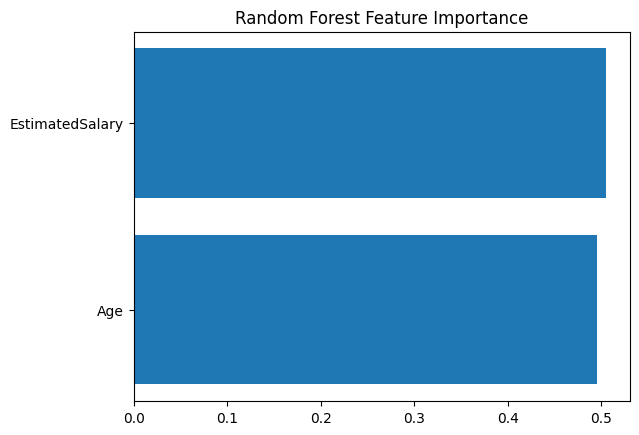

In [ ]:
social_df = pd.read_csv('Social_Network_Ads.csv')

# Drop User ID if exists
if 'User ID' in social_df.columns:
    social_df = social_df.drop('User ID', axis=1)

# Encode Gender
if 'Gender' in social_df.columns:
    social_df['Gender'] = LabelEncoder().fit_transform(social_df['Gender'])

X_social = social_df.drop('Purchased', axis=1)
y_social = social_df['Purchased']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_social, y_social, test_size=0.2, random_state=42
)

# Scale data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_s)
X_test_s = scaler.transform(X_test_s)

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train_s, y_train_s)

y_pred_s = rf_model.predict(X_test_s)

print("Random Forest Accuracy:", accuracy_score(y_test_s, y_pred_s))

# Confusion Matrix
cm_s = confusion_matrix(y_test_s, y_pred_s)
ConfusionMatrixDisplay(cm_s).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

# Feature Importance
plt.figure()
plt.barh(X_social.columns, rf_model.feature_importances_)
plt.title("Random Forest Feature Importance")
plt.show()

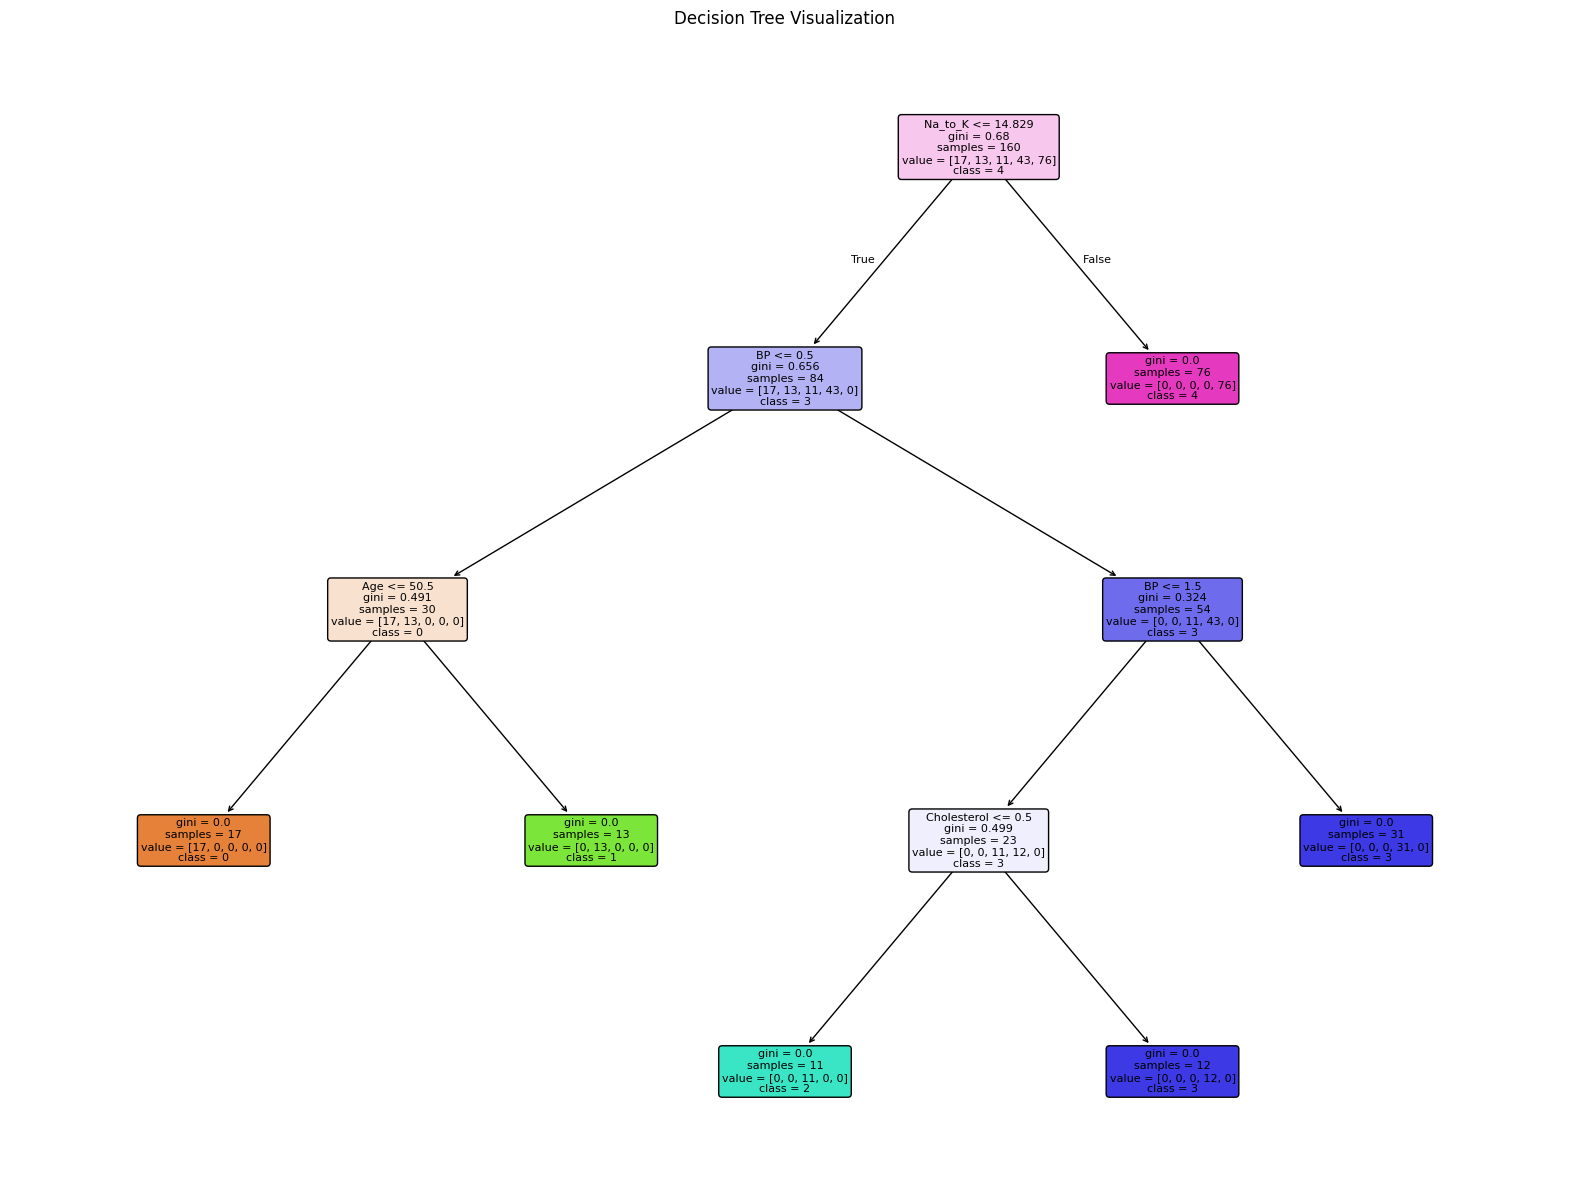

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Assuming 'dt_model', 'X_drug', and 'y_drug' are already defined and fitted from previous cells

# Get class names for the target variable (Drug)
# If y_drug is already label encoded, we can get unique values.
# Otherwise, if we have the original 'Drug' column, we can use that.
# For this example, let's assume y_drug contains the encoded classes and we need to map them back if possible
# Or, directly use the unique encoded values as class names.
class_names = [str(c) for c in sorted(y_drug.unique())]

plt.figure(figsize=(20, 15)) # Adjust figure size for better readability
plot_tree(dt_model,
          feature_names=X_drug.columns.tolist(),
          class_names=class_names,
          filled=True,
          rounded=True,
          fontsize=8)
plt.title("Decision Tree Visualization")
plt.show()

If you want to upload to Google Drive instead, let me know, and I can provide code for mounting your Google Drive.